In [1]:
# -------------------------
# Step 1: Imports & Configuration (Run First)
# -------------------------
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F  # Add this line at the top
from sklearn.metrics import mean_squared_error  # Add this line
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os

# Configuration
MOBILITY = 120  # kmph
COMPRESSION_RATIO = '1/16'
INPUT_DIM = 128   # uma128.csv has 128 columns
OUTPUT_DIM = 8    # 128 * (1/16) = 8
SEQ_LEN = 12      # From paper
PRED_LEN = 5      # From paper
EPOCHS = 150      # Extended training
BATCH_SIZE = 50
LR = 0.00005      # Reduced learning rate
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------
# Step 2: Dataset Preparation (Run Second)
# -------------------------
class CSIDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path, header=None)
        self.scaler = StandardScaler()
        self.data = self.scaler.fit_transform(self.df.values)
        
    def __len__(self):
        return len(self.data) - SEQ_LEN - PRED_LEN

    def __getitem__(self, idx):
        x = self.data[idx:idx+SEQ_LEN]
        y = self.data[idx+SEQ_LEN:idx+SEQ_LEN+PRED_LEN]
        return torch.FloatTensor(x), torch.FloatTensor(y)

# Initialize dataset and loader
dataset = CSIDataset(r"C:\Users\Aftab Dayer\Desktop\Thesis\dataset\Uma_128.csv")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# -------------------------
# Step 3: Optimized Model Architecture (Run Third)
# -------------------------
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
        
    def forward(self, h):
        # h shape: [batch, seq, features]
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)  # Now uses imported F
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))  # Fixed here

class LSTMNet(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=8, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        # x: [batch, seq, features]
        _, (hn, _) = self.lstm(x)
        out = hn[-1]  # last layer's hidden state
        return self.fc(out)
        
# Instantiate
model = LSTMNet().to(DEVICE)


# -------------------------
# Step 4: Training Setup (Run Fourth)
# -------------------------
model = LSTMNet().to(DEVICE)
optimizer = optim.RMSprop(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.MSELoss()

# -------------------------
# Step 5: Training Loop (Run Fifth)
# -------------------------
def train_model():
    metrics = {'loss': [], 'rmse': [], 'se': []}
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for x, y in loader:
            x = x.to(DEVICE)
            y = y[:, -1, :OUTPUT_DIM].to(DEVICE)  # Critical dimensional fix
            
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        rmse, se = 0, 0
        with torch.no_grad():
            for x, y in loader:
                x = x.to(DEVICE)
                y_true = y[:, -1, :OUTPUT_DIM].cpu()
                pred = model(x).cpu()
                
                rmse += np.sqrt(mean_squared_error(y_true, pred))  # Now works
                se += spectral_efficiency(y_true, pred)
        
        metrics['loss'].append(epoch_loss/len(loader))
        metrics['rmse'].append(rmse/len(loader))
        metrics['se'].append(se/len(loader))
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {metrics['loss'][-1]:.4f} | RMSE: {metrics['rmse'][-1]:.4f} | SE: {metrics['se'][-1]:.4f}")
    
    return metrics

def spectral_efficiency(y_true, y_pred, snr_db=30):
    noise_var = 10 ** (-snr_db / 10)
    signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
    interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
    sinr = signal_power / (interference + noise_var)
    return np.log2(1 + sinr)


# -------------------------
# Step 6: Execute Training (Run Sixth)
# -------------------------
print(f"\n=== Training {COMPRESSION_RATIO} Compression ===")
metrics = train_model()


=== Training 1/16 Compression ===
Epoch 1/150 | Loss: 0.9048 | RMSE: 0.8922 | SE: 0.0582
Epoch 2/150 | Loss: 0.6739 | RMSE: 0.7490 | SE: 0.4246
Epoch 3/150 | Loss: 0.4876 | RMSE: 0.6482 | SE: 0.9062
Epoch 4/150 | Loss: 0.3666 | RMSE: 0.5579 | SE: 1.3772
Epoch 5/150 | Loss: 0.2626 | RMSE: 0.4618 | SE: 1.9592
Epoch 6/150 | Loss: 0.1789 | RMSE: 0.3834 | SE: 2.5776
Epoch 7/150 | Loss: 0.1269 | RMSE: 0.3274 | SE: 3.0802
Epoch 8/150 | Loss: 0.0948 | RMSE: 0.2857 | SE: 3.5052
Epoch 9/150 | Loss: 0.0733 | RMSE: 0.2529 | SE: 3.8761
Epoch 10/150 | Loss: 0.0579 | RMSE: 0.2255 | SE: 4.2183
Epoch 11/150 | Loss: 0.0464 | RMSE: 0.2025 | SE: 4.5491
Epoch 12/150 | Loss: 0.0379 | RMSE: 0.1836 | SE: 4.8434
Epoch 13/150 | Loss: 0.0314 | RMSE: 0.1679 | SE: 5.1060
Epoch 14/150 | Loss: 0.0264 | RMSE: 0.1541 | SE: 5.3604
Epoch 15/150 | Loss: 0.0224 | RMSE: 0.1422 | SE: 5.6023
Epoch 16/150 | Loss: 0.0192 | RMSE: 0.1321 | SE: 5.8035
Epoch 17/150 | Loss: 0.0167 | RMSE: 0.1236 | SE: 5.9958
Epoch 18/150 | Loss: 0

In [ ]:
# After training:
torch.save(lstm_model.state_dict(), 'lstm_model.pth')


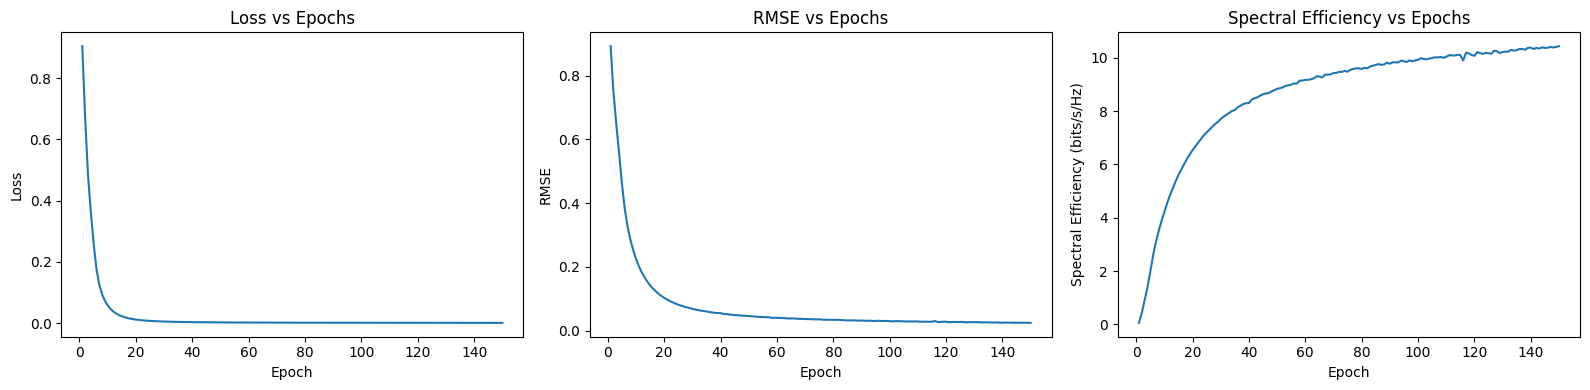

In [2]:
import pickle
import matplotlib.pyplot as plt

# SAVE metrics as a pickle file for easy loading later
with open('lstm_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
# ...similarly for CNN: cnn_metrics.pkl


# PLOT Loss, RMSE, SE vs. Epochs
epochs = range(1, len(metrics['loss'])+1)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.plot(epochs, metrics['loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, metrics['rmse'])
plt.title('RMSE vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.subplot(1,3,3)
plt.plot(epochs, metrics['se'])
plt.title('Spectral Efficiency vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Spectral Efficiency (bits/s/Hz)')

plt.tight_layout()
plt.savefig('gat_training_curves.png', dpi=300)
plt.show()


In [3]:
import pickle

with open('gat_metrics.pkl', 'rb') as f:
    gat_metrics = pickle.load(f)
with open('lstm_metrics.pkl', 'rb') as f:
    lstm_metrics = pickle.load(f)
with open('cnn_metrics.pkl', 'rb') as f:
    cnn_metrics = pickle.load(f)


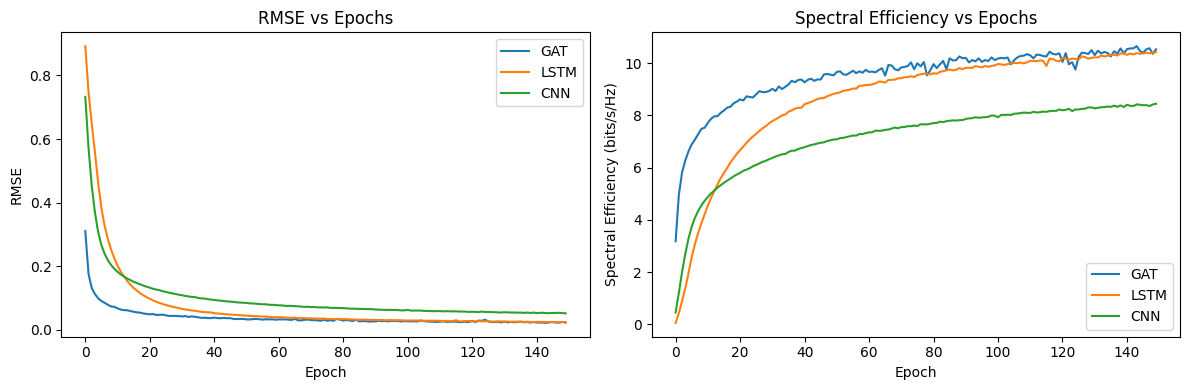

In [4]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(gat_metrics['rmse'], label='GAT')
plt.plot(lstm_metrics['rmse'], label='LSTM')
plt.plot(cnn_metrics['rmse'], label='CNN')
plt.title('RMSE vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(gat_metrics['se'], label='GAT')
plt.plot(lstm_metrics['se'], label='LSTM')
plt.plot(cnn_metrics['se'], label='CNN')
plt.title('Spectral Efficiency vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Spectral Efficiency (bits/s/Hz)')
plt.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()


In [5]:
import pandas as pd

data = {
    'Model': ['GAT', 'LSTM', 'CNN'],
    'Final RMSE': [
        gat_metrics['rmse'][-1],
        lstm_metrics['rmse'][-1],
        cnn_metrics['rmse'][-1]
    ],
    'Final SE': [
        gat_metrics['se'][-1],
        lstm_metrics['se'][-1],
        cnn_metrics['se'][-1]
    ]
}

df = pd.DataFrame(data)
print(df)

# Save as CSV for thesis/paper
df.to_csv('model_comparison_table.csv', index=False)


  Model  Final RMSE   Final SE
0   GAT    0.023409  10.534341
1  LSTM    0.024498  10.430519
2   CNN    0.052288   8.447338


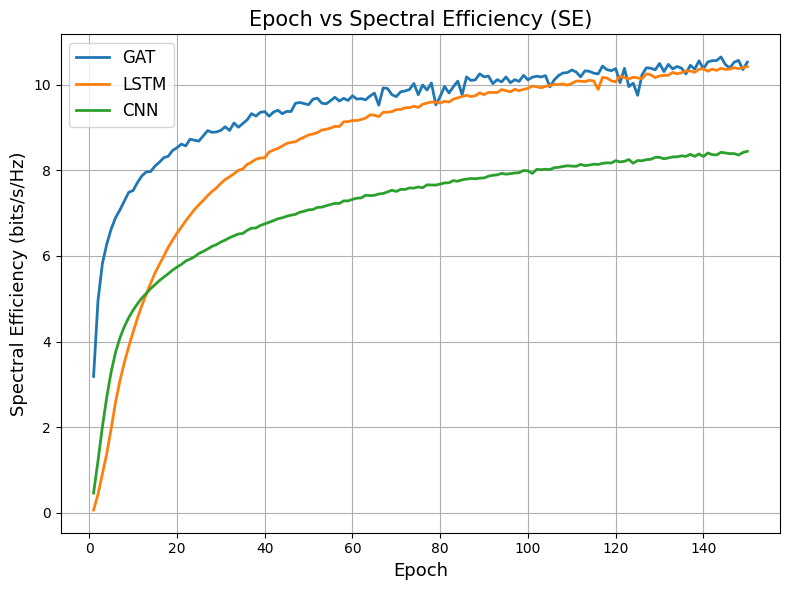

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(gat_metrics['se']) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, gat_metrics['se'], label='GAT', linewidth=2)
plt.plot(epochs, lstm_metrics['se'], label='LSTM', linewidth=2)
plt.plot(epochs, cnn_metrics['se'], label='CNN', linewidth=2)

plt.title('Epoch vs Spectral Efficiency (SE)', fontsize=15)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Spectral Efficiency (bits/s/Hz)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('comparison_epoch_vs_se.png', dpi=300)
plt.show()
